In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt


## My files
import save_data_helpers
import recon_plot_helpers
from ismrm_figs import mvf_utils

### Load data

In [2]:
# base_dir = '/data/lilianae/ADMM_results/400sp_George/recon_output'
# base_dir = '/data/lilianae/ADMM_results/sweep_20251105_163705/' ## 100 spokes
# base_dir = '/data/lilianae/ADMM_results/sweep_20251108_213241/' ## 50 spokes
base_dir = '/data/lilianae/ADMM_results/no_norm_admm_z_base_original_parms/'
iter_num = 7

## Select sweep directory
# sweep_dir_high_beta = 'high_beta_tv_z_rho_0.01_beta_0.005_lam_0.007'
# sweep_dir_original = 'original_z_rho_0.01_beta_0.0001_lam_0.001'
# sweep_dir_strong = 'strong_coupling_z_rho_0.05_beta_0.0005_lam_0.005'
# sweep_dir_very_strong = 'very_strong_z_rho_0.1_beta_0.001_lam_0.005'
# sweep_dir = sweep_dir_very_strong


z_abs, lam_abs, mvf_admm_512, mvf_inv_admm_512 = mvf_utils.load_admm_output(base_dir, iter_num)

tmp_inv_admm.shape = (5, 58, 512, 512, 3)
tmp_admm.shape = (5, 58, 512, 512, 3)
z_abs.shape = (5, 58, 512, 512)


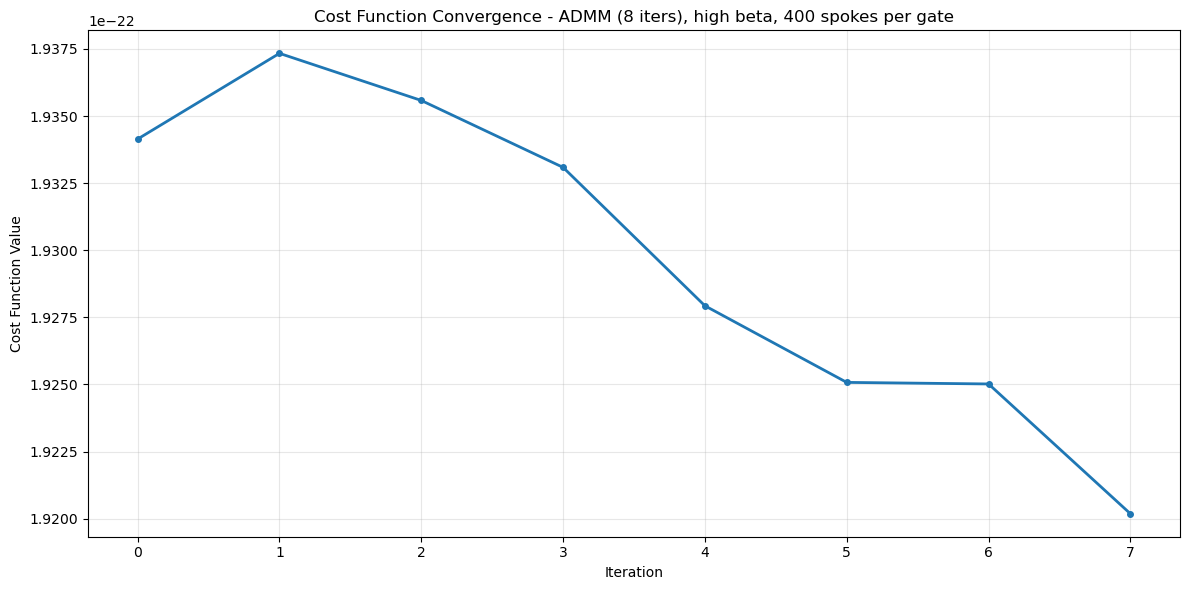

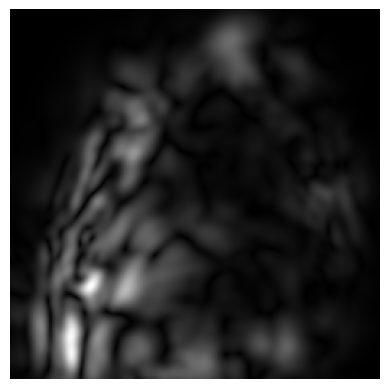

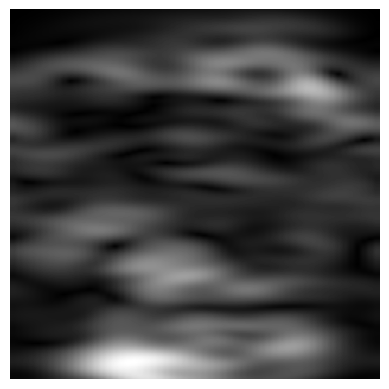

In [3]:
import json

def plot_cost_comparison(base_dir):
    """Compare cost function evolution across tests"""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    

    cost_path = os.path.join(base_dir, "cost.json")
    if os.path.exists(cost_path):
        with open(cost_path, 'r') as f:
            cost_data = json.load(f)
            cost_values = cost_data['cost']
            
            short_name = base_dir.replace("mini_admm_", "").split("_beta_")[0]
            ax.plot(cost_values, 'o-', label=short_name, linewidth=2, markersize=4)
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost Function Value')
    ax.set_title('Cost Function Convergence - ADMM (8 iters), high beta, 400 spokes per gate')
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # save_path = os.path.join(output_path, 'cost_plot_100sp.png')
    # plt.savefig(save_path)
    plt.show()

# plot_cost_comparison(f'{base_dir}/{sweep_dir}')
plot_cost_comparison(f'{base_dir}')

oshape = (58, 256, 256)
cropped_img = recon_plot_helpers.crop_xy_dimension(lam_abs, oshape=oshape)
# recon_plot_helpers.plot_recons_all_axes(cropped_img, z_idx=58//2, title=rf'ADMM (8 iters): Final motion corrected image, 400 spokes per gate')
recon_plot_helpers.plot_recon_single_axis(cropped_img, slice_axis=0, slice_idx=40)
recon_plot_helpers.plot_recon_single_axis(cropped_img, slice_axis=2, slice_idx=128)

In [4]:
# After loading lambda from .npz file

print(f"Lambda statistics:")
print(f"  Min: {lam_abs.min():.6f}")
print(f"  Max: {lam_abs.max():.6f}")
print(f"  Mean: {lam_abs.mean():.6f}")
print(f"  Std: {lam_abs.std():.6f}")

# Compare with z_k
print(f"\nZ[0] statistics:")
print(f"  Min: {z_abs.min():.6f}")
print(f"  Max: {z_abs.max():.6f}")
print(f"  Mean: {z_abs.mean():.6f}")
print(f"  Std: {z_abs.std():.6f}")

Lambda statistics:
  Min: 0.000000
  Max: 0.000000
  Mean: 0.000000
  Std: 0.000000

Z[0] statistics:
  Min: 0.000000
  Max: 0.000000
  Mean: 0.000000
  Std: 0.000000


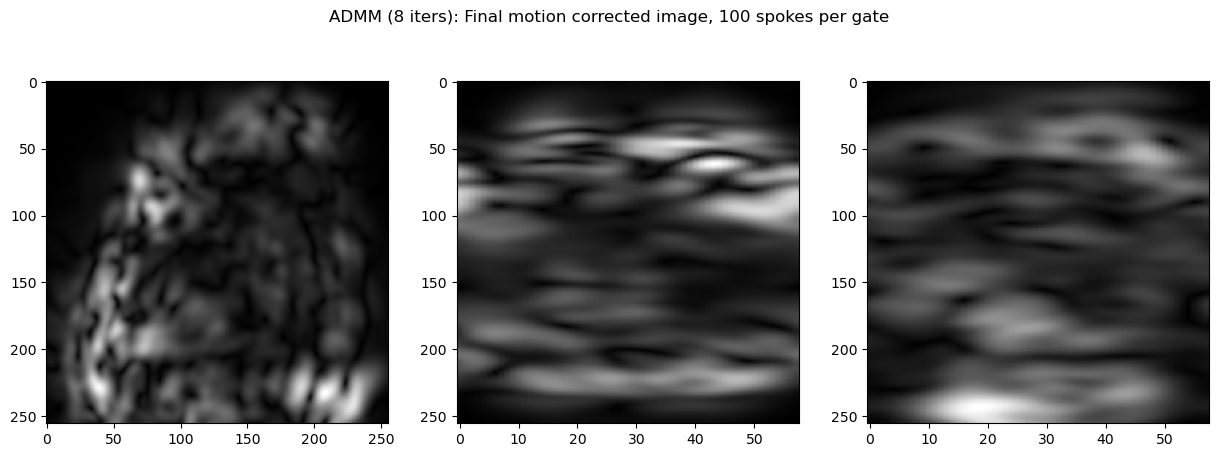

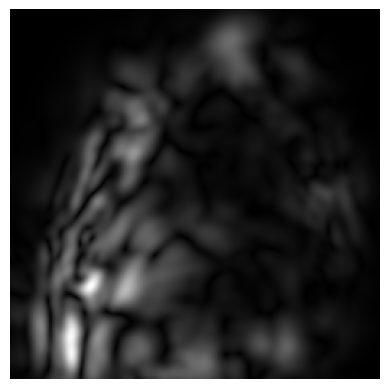

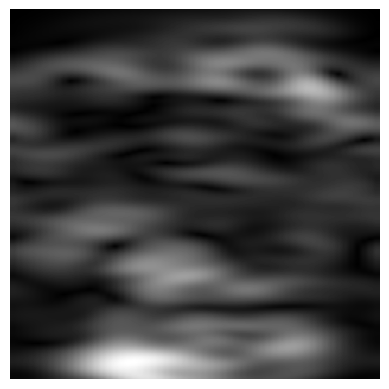

In [6]:
oshape = (58, 256, 256)
cropped_img = recon_plot_helpers.crop_xy_dimension(lam_abs, oshape=oshape)
recon_plot_helpers.plot_recons_all_axes(cropped_img, z_idx=58//2, title=rf'ADMM (8 iters): Final motion corrected image, 100 spokes per gate')
recon_plot_helpers.plot_recon_single_axis(cropped_img, slice_axis=0, slice_idx=40)
recon_plot_helpers.plot_recon_single_axis(cropped_img, slice_axis=2, slice_idx=128)

### Show lambda

In [ ]:
# save_data_helpers.write_pickle(cropped_img, '/home/lilianae/projects/naf_clean/ismrm_figs/lam_abs_cropped_admm_400sp_8iters.pkl')

### View gated recons

New array shape = (5, 58, 256, 256)


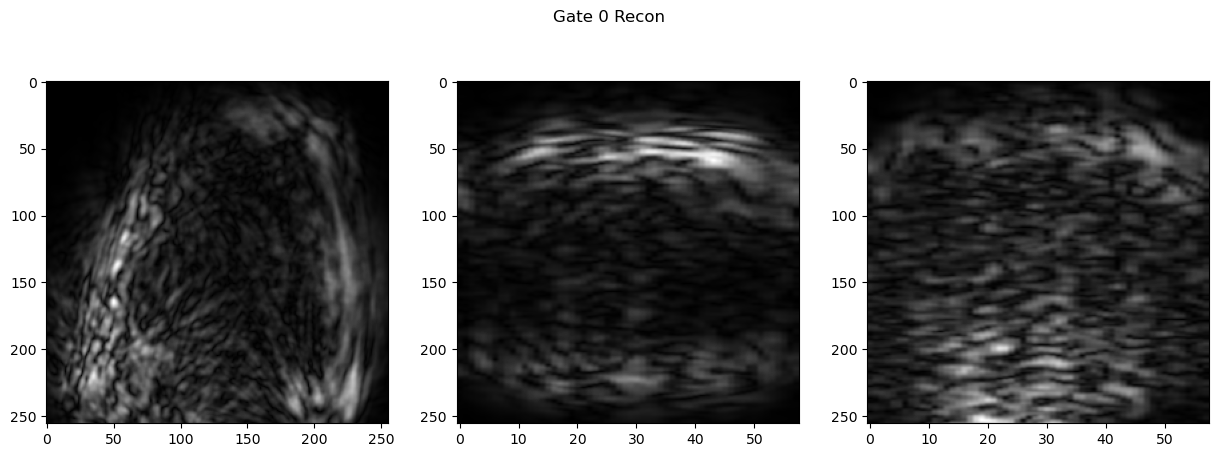

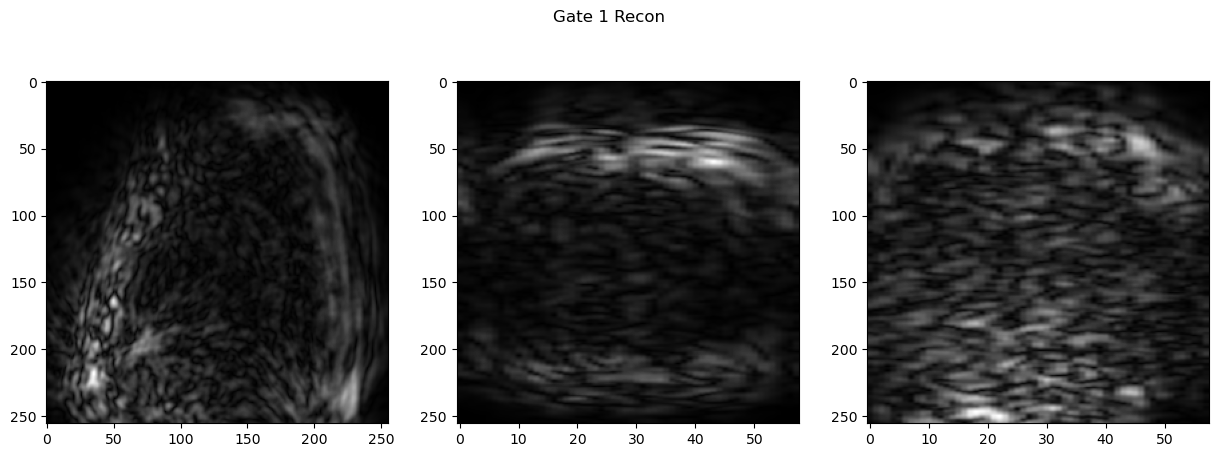

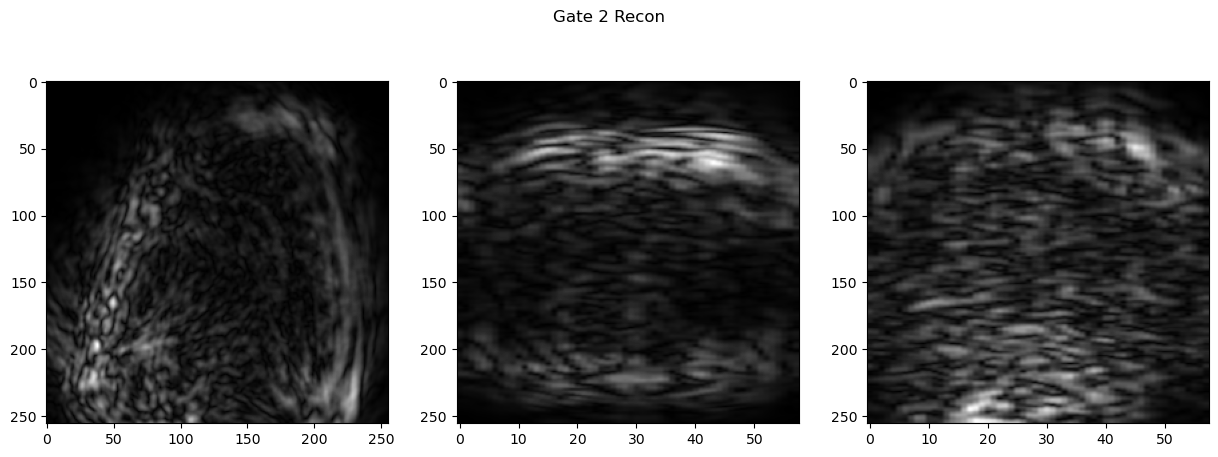

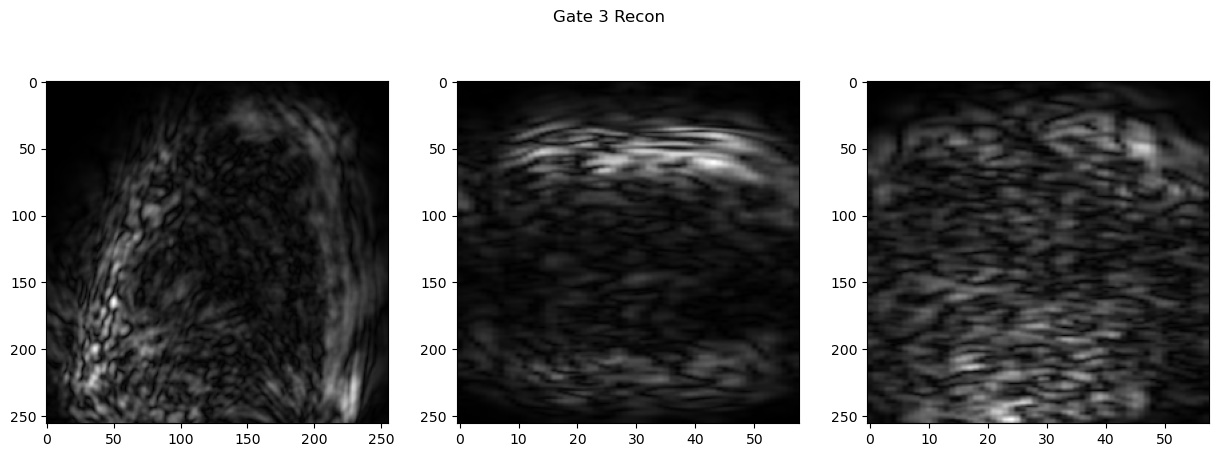

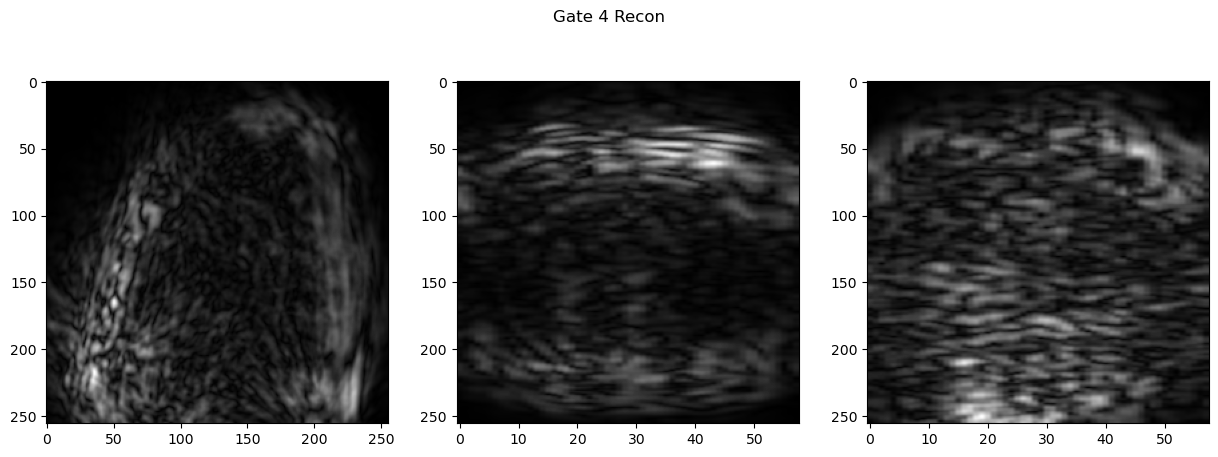

In [9]:
oshape = (58, 256, 256)
gated_images = mvf_utils.crop_gated_imgs(z_abs, oshape)
for i in range(len(z_abs)):
    recon_plot_helpers.plot_recons_all_axes(gated_images[i], title=f'Gate {i} Recon')

### Make gif

In [ ]:
# recon_plot_helpers.make_gif(gated_images, slice_axis=2, 
#                             gif_name=f"/home/lilianae/projects/naf_clean/admm_results/400sp_lam0.001_beta0.0001/admm_400sp_iter{iter_num}_coronal")

In [ ]:
# import json

# def plot_cost_comparison(base_dir):
#     """Compare cost function evolution across tests"""
    
#     fig, ax = plt.subplots(figsize=(12, 6))
    

#     cost_path = os.path.join(base_dir, "cost.json")
#     if os.path.exists(cost_path):
#         with open(cost_path, 'r') as f:
#             cost_data = json.load(f)
#             cost_values = cost_data['cost']
            
#             short_name = base_dir.replace("mini_admm_", "").split("_beta_")[0]
#             ax.plot(cost_values, 'o-', label=short_name, linewidth=2, markersize=4)
    
#     ax.set_xlabel('Iteration')
#     ax.set_ylabel('Cost Function Value')
#     ax.set_title('Cost Function Convergence - ADMM (8 iters), high beta, 400 spokes per gate')
#     # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     # save_path = os.path.join(output_path, 'cost_plot_100sp.png')
#     # plt.savefig(save_path)
#     plt.show()

# plot_cost_comparison(f'{base_dir}/{sweep_dir_strong}')